# FhEFL — Min-Max Attack Results
Comprehensive analysis and comparison figures for min-max attacks across datasets.

In [1]:
import ast, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── IEEE journal style ──────────────────────────────────────────
rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "legend.framealpha": 0.9,
    "lines.linewidth": 1.4,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

RESULTS_DIR = "."   # run from FedAvg/results/
PLOTS_DIR   = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Method registry ─────────────────────────────────────────────
METHODS = {
    "FedAvg":        {"dir": "fedAvg",  "color": "#ff7f0e", "ls": "--", "lw": 1, "marker": "s"},
    "Trimmed-Mean":  {"dir": "mean",    "color": "#2ca02c", "ls": "-.", "lw": 1, "marker": "^"},
    "Median":        {"dir": "median",  "color": "#d62728", "ls": ":",  "lw": 1, "marker": "D"},
    "KRUM":          {"dir": "krum",    "color": "#9467bd", "ls": "--", "lw": 1, "marker": "v"},
    "FLTrust":       {"dir": "fltrust", "color": "#8c564b", "ls": "-.", "lw": 1, "marker": "p"},
    "DP-FL":         {"dir": "dp_fl",   "color": "#e377c2", "ls": ":",  "lw": 1, "marker": "h"},
    "BREA":          {"dir": "brea",    "color": "#7f7f7f", "ls": "--", "lw": 1, "marker": "*"},
    "RSA":           {"dir": "rsa",     "color": "#bcbd22", "ls": "-",  "lw": 1, "marker": "x"},
    "FhEFL (Ours)": {"dir": "e_d",     "color": "#1f77b4", "ls": "-",  "lw": 2.2, "marker": "o"}
}

def load(method_dir, filename):
    """Load a result list; return None if file missing or empty."""
    path = os.path.join(RESULTS_DIR, method_dir, filename)
    if not os.path.exists(path):
        return None
    try:
        data = ast.literal_eval(open(path).read().strip())
        return [float(v) * 100 for v in data] if data else None
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

def smooth(data, w=5):
    """Simple moving-average smoothing."""
    if len(data) < w:
        return data
    kernel = np.ones(w) / w
    pad = np.pad(data, (w//2, w//2), mode="edge")
    return np.convolve(pad, kernel, mode="valid")[:len(data)]

print("Setup complete. Methods:", list(METHODS.keys()))

Setup complete. Methods: ['FedAvg', 'Trimmed-Mean', 'Median', 'KRUM', 'FLTrust', 'DP-FL', 'BREA', 'RSA', 'FhEFL (Ours)']


## 1. Helper Functions

In [2]:
def plot_panel(ax, dataset, n_attackers, metric, attack_suffix="_min_max",
               methods=None, every=10, do_smooth=True, ylim=None):
    """Plot one panel (one dataset / attacker count combination)."""
    if methods is None:
        methods = list(METHODS.keys())
    filename = f"{metric}_{dataset}_{n_attackers}{attack_suffix}.txt"
    plotted = []
    for name in methods:
        cfg = METHODS[name]
        data = load(cfg["dir"], filename)
        if data is None:
            continue
        xs = list(range(1, len(data) + 1))
        ys = smooth(data) if do_smooth else data
        ax.plot(xs, ys, color=cfg["color"], ls=cfg["ls"], lw=cfg["lw"],
                label=name, markevery=every, marker=cfg["marker"],
                markersize=4, markeredgewidth=0.6)
        plotted.append(name)
    ax.set_xlabel("Communication Round")
    if metric == "accuracy":
        ax.set_ylabel("Test Accuracy (%)")
        if ylim: ax.set_ylim(ylim)
    else:
        ax.set_ylabel("Attack Success Rate (%)")
    return plotted

DATASET_LABELS = {"mnist": "MNIST", "cifar": "CIFAR-10", "cifar-100": "CIFAR-100"}
DATASET_ORDER = ["mnist", "cifar"]

def final_val(method_dir, filename, last_n=10):
    """Extract final value (average of last N rounds)."""
    data = load(method_dir, filename)
    if data is None:
        return float("nan")
    return float(np.mean(data[-last_n:]))

print("Helper functions loaded.")

Helper functions loaded.


## 2. Min-Max Attack: Accuracy Comparison (f=20)

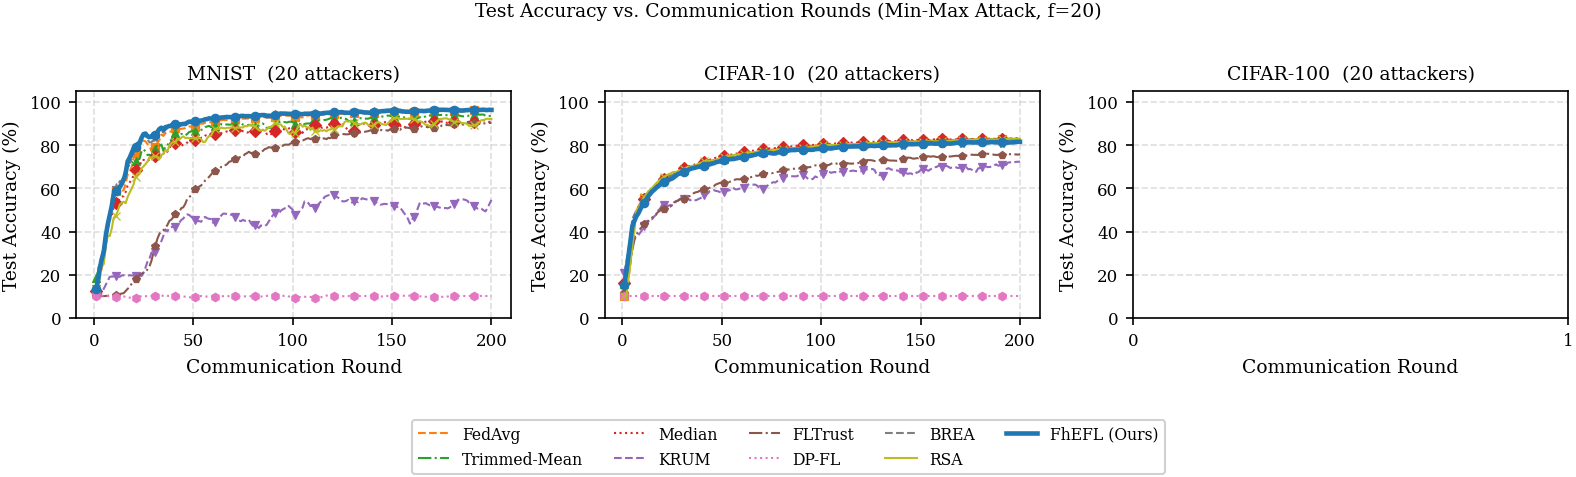

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10.74, 2.6), sharey=False)
configs = [("mnist", 20, 200), ("cifar", 20, 200), ("cifar-100", 20, 200)]

for ax, (ds, na, ep) in zip(axs, configs):
    plotted = plot_panel(ax, ds, na, "accuracy", attack_suffix="_min_max", 
                          every=max(1, ep//20))
    ax.set_title(f"{DATASET_LABELS[ds]}  ({na} attackers)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))
    ax.set_ylim([0, 105])

# Shared legend below the figure
fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.22),
           frameon=True, handlelength=2)
fig.suptitle("Test Accuracy vs. Communication Rounds (Min-Max Attack, f=20)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_accuracy_min_max_20.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_accuracy_min_max_20.png")
plt.show()

## 3. Min-Max Attack: ASR Comparison (f=20)

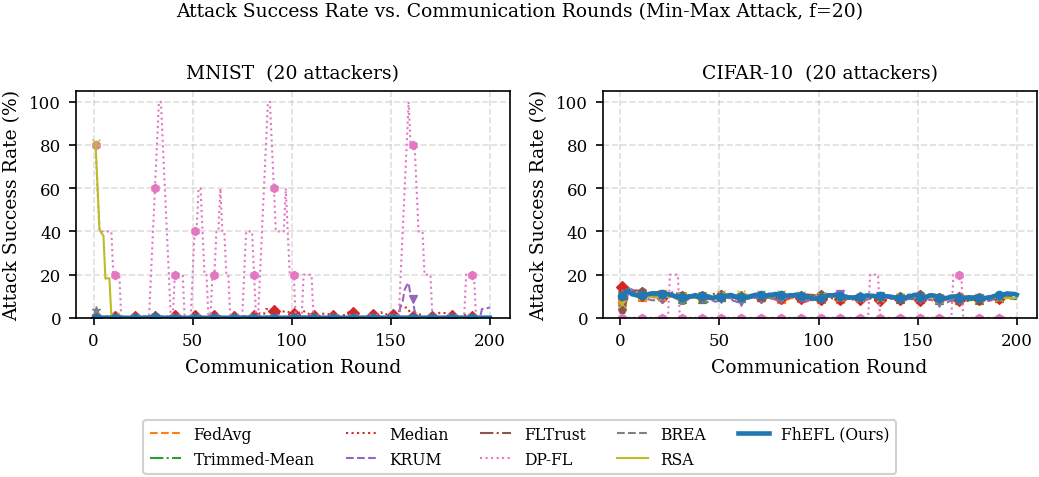

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(7.16, 2.6))
configs = [("mnist", 20, 200), ("cifar", 20, 200)]

for ax, (ds, na, ep) in zip(axs, configs):
    plot_panel(ax, ds, na, "asr", attack_suffix="_min_max", 
               every=max(1, ep//20))
    ax.set_title(f"{DATASET_LABELS[ds]}  ({na} attackers)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))
    ax.set_ylim([0, 105])

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.22),
           frameon=True, handlelength=2)
fig.suptitle("Attack Success Rate vs. Communication Rounds (Min-Max Attack, f=20)", fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_asr_min_max_20.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_asr_min_max_20.png")
plt.show()

## 4. Final Values Bar Charts (Min-Max, f=20)

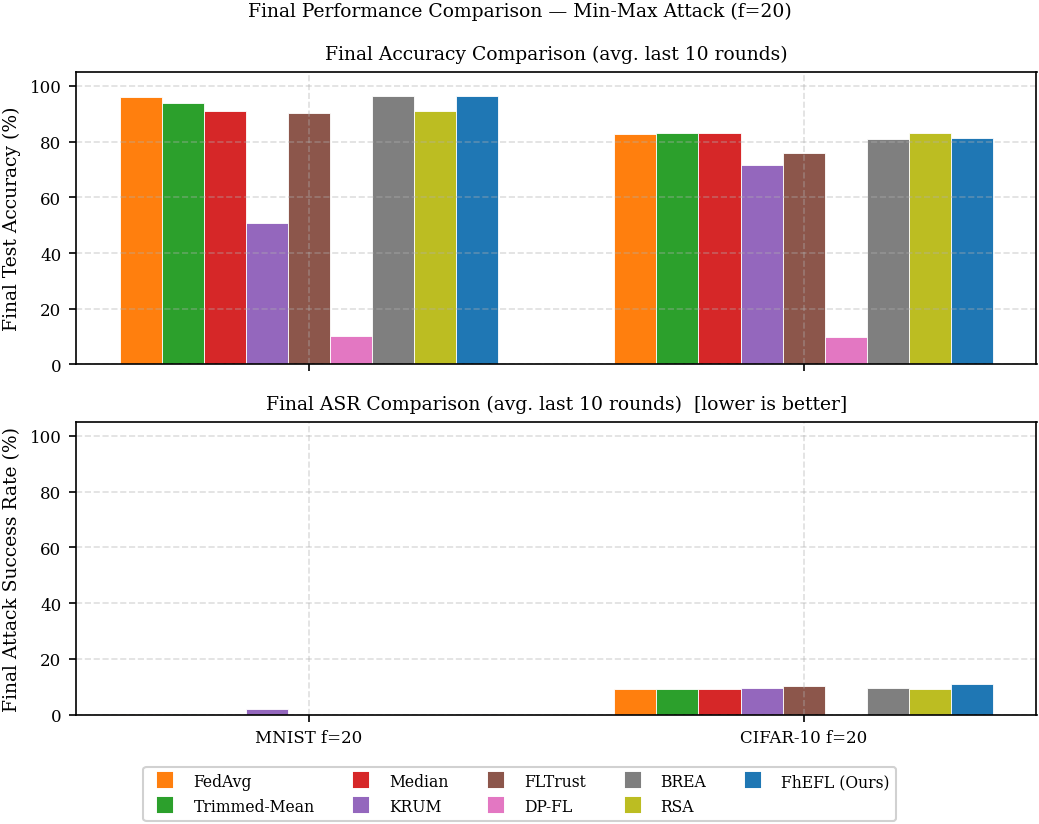

In [5]:
# ── Final accuracy and ASR bars ─────────────────────────────────
EVAL_CONFIGS = [
    ("MNIST f=20",     "accuracy_mnist_20_min_max.txt",      "asr_mnist_20_min_max.txt"),
    ("CIFAR-10 f=20",  "accuracy_cifar_20_min_max.txt",      "asr_cifar_20_min_max.txt"),
]

n_methods = len(METHODS)
n_configs = len(EVAL_CONFIGS)
x = np.arange(n_configs)
bar_w = 0.085
offsets = np.linspace(-(n_methods - 1) * bar_w / 2,
                       (n_methods - 1) * bar_w / 2, n_methods)

fig, (ax_acc, ax_asr) = plt.subplots(2, 1, figsize=(7.16, 5.2), sharex=True)

for i, (name, cfg) in enumerate(METHODS.items()):
    acc_vals = [final_val(cfg["dir"], acc_f) for _, acc_f, _ in EVAL_CONFIGS]
    asr_vals = [final_val(cfg["dir"], asr_f) for _, _, asr_f in EVAL_CONFIGS]
    pos = x + offsets[i]
    for j, (av, sv) in enumerate(zip(acc_vals, asr_vals)):
        # skip NaN bars — experiments may still be running
        if not np.isnan(av):
            ax_acc.bar(pos[j], av, bar_w, color=cfg["color"],
                       edgecolor="white", linewidth=0.4,
                       label=name if j == 0 else "_")
        if not np.isnan(sv):
            ax_asr.bar(pos[j], sv, bar_w, color=cfg["color"],
                       edgecolor="white", linewidth=0.4)

ax_acc.set_ylabel("Final Test Accuracy (%)")
ax_acc.set_title("Final Accuracy Comparison (avg. last 10 rounds)")
ax_acc.set_ylim(0, 105)
ax_asr.set_ylabel("Final Attack Success Rate (%)")
ax_asr.set_title("Final ASR Comparison (avg. last 10 rounds)  [lower is better]")
ax_asr.set_ylim(0, 105)
ax_asr.set_xticks(x)
ax_asr.set_xticklabels([c[0] for c in EVAL_CONFIGS], rotation=0)

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"],
                            marker="s", markersize=7, ls="", label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.08), frameon=True)
fig.suptitle("Final Performance Comparison — Min-Max Attack (f=20)", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_bar_min_max_final_accuracy_asr.pdf")
plt.savefig(f"{PLOTS_DIR}/fig_bar_min_max_final_accuracy_asr.png")
plt.show()

## 5. Detailed Comparison Table (Min-Max Attack)

In [6]:
import pandas as pd

rows = []
for name, cfg in METHODS.items():
    row = {"Method": name}
    row["MNIST Acc (f=20)"]  = f"{final_val(cfg['dir'], 'accuracy_mnist_20_min_max.txt'):.1f}"
    row["MNIST ASR (f=20)"]  = f"{final_val(cfg['dir'], 'asr_mnist_20_min_max.txt'):.1f}"
    row["CIFAR-10 Acc (f=20)"]  = f"{final_val(cfg['dir'], 'accuracy_cifar_20_min_max.txt'):.1f}"
    row["CIFAR-10 ASR (f=20)"]  = f"{final_val(cfg['dir'], 'asr_cifar_20_min_max.txt'):.1f}"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
df.replace("nan", "—", inplace=True)
print(df)
print("\n\nLatex Table:")
print(df.to_latex())
df.to_csv(f"{PLOTS_DIR}/summary_table_min_max.csv")

             MNIST Acc (f=20) MNIST ASR (f=20) CIFAR-10 Acc (f=20)  \
Method                                                               
FedAvg                   96.1              0.0                82.8   
Trimmed-Mean             93.9              0.1                83.0   
Median                   91.0              0.4                83.1   
KRUM                     50.8              2.2                71.6   
FLTrust                  90.1              0.1                75.8   
DP-FL                    10.1              0.0                10.0   
BREA                     96.5              0.0                81.0   
RSA                      91.0              0.0                82.9   
FhEFL (Ours)             96.4              0.1                81.4   

             CIFAR-10 ASR (f=20)  
Method                            
FedAvg                       9.3  
Trimmed-Mean                 9.2  
Median                       9.1  
KRUM                         9.6  
FLTrust            

ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

## 6. Side-by-side Accuracy Comparison (3x3 Grid)

In [ ]:
# Create a 3x3 grid showing accuracy for each method
# Rows: Datasets (MNIST, CIFAR-10, [empty])
# Columns: Different perspectives

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

# Panel 1: MNIST Accuracy
ax = axs[0]
plot_panel(ax, "mnist", 20, "accuracy", attack_suffix="_min_max", every=20)
ax.set_title("MNIST — Test Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 2: CIFAR-10 Accuracy  
ax = axs[1]
plot_panel(ax, "cifar", 20, "accuracy", attack_suffix="_min_max", every=20)
ax.set_title("CIFAR-10 — Test Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 3: MNIST ASR
ax = axs[2]
plot_panel(ax, "mnist", 20, "asr", attack_suffix="_min_max", every=20)
ax.set_title("MNIST — Attack Success Rate (f=20)")
ax.set_ylim([0, 105])

# Panel 4: CIFAR-10 ASR
ax = axs[3]
plot_panel(ax, "cifar", 20, "asr", attack_suffix="_min_max", every=20)
ax.set_title("CIFAR-10 — Attack Success Rate (f=20)")
ax.set_ylim([0, 105])

# Shared legend
fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=True)
fig.suptitle("Min-Max Attack: Accuracy & ASR Comparison (f=20 attackers)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_grid_min_max_comprehensive.pdf", bbox_inches="tight")
plt.savefig(f"{PLOTS_DIR}/fig_grid_min_max_comprehensive.png", bbox_inches="tight")
plt.show()

## 7. Comparison: Label-Flipping vs Min-Max (MNIST)

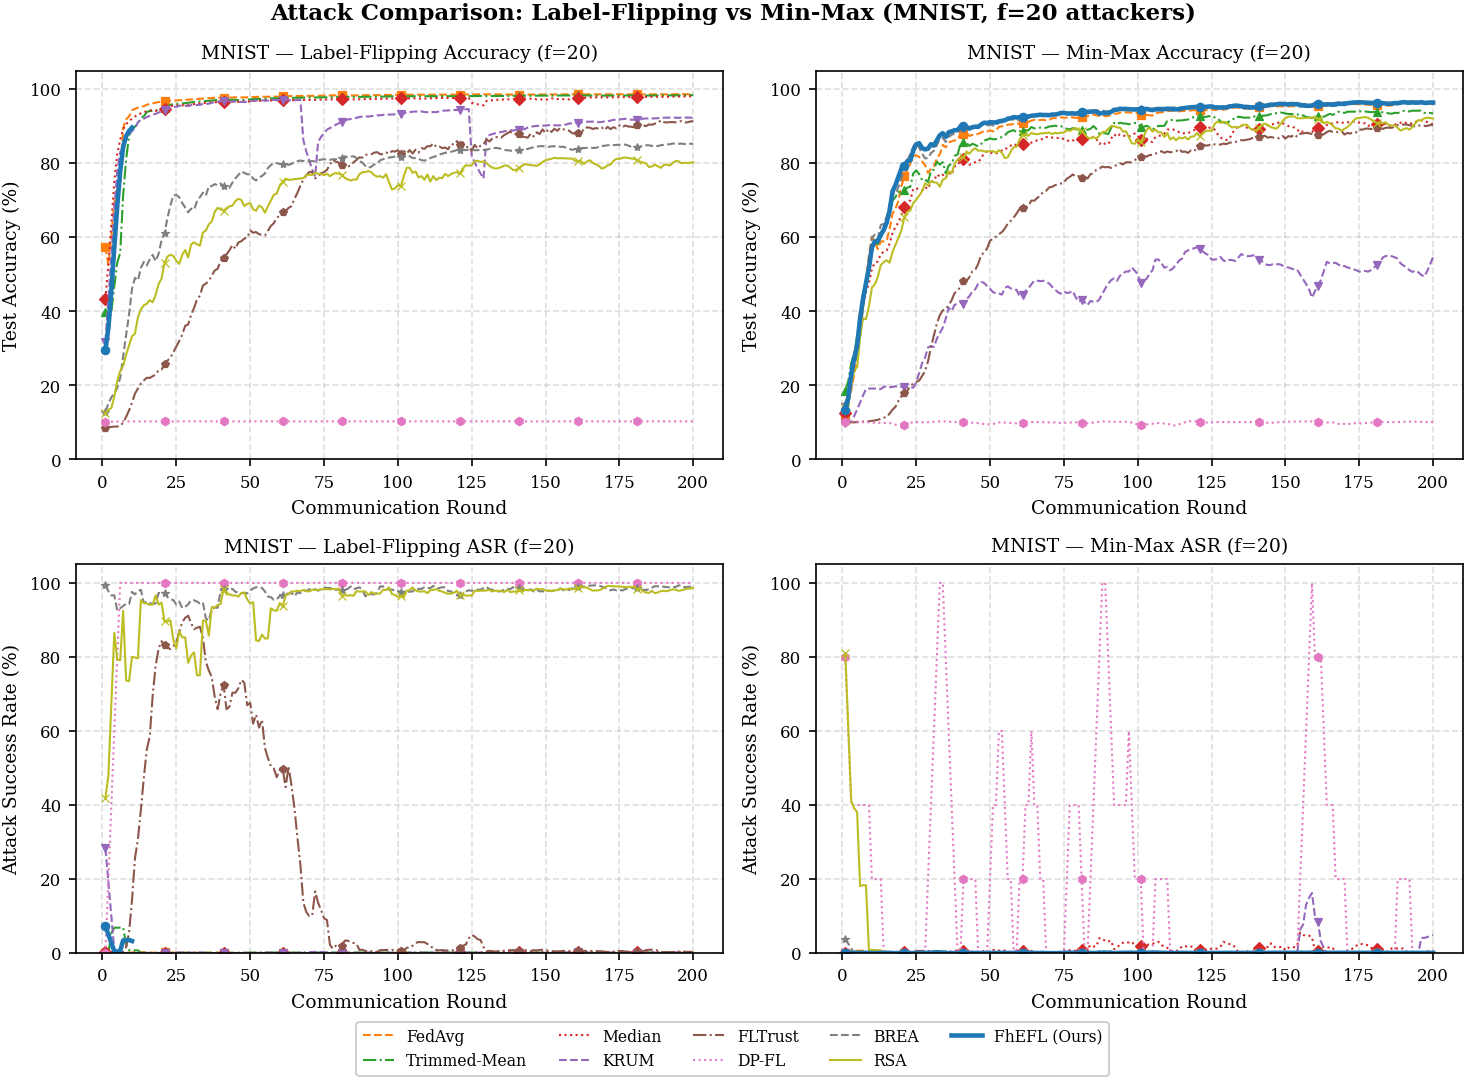

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs = axs.flatten()

# Panel 1: MNIST Accuracy - Label-Flipping
ax = axs[0]
plot_panel(ax, "mnist", 20, "accuracy", attack_suffix="", every=20)
ax.set_title("MNIST — Label-Flipping Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 2: MNIST Accuracy - Min-Max
ax = axs[1]
plot_panel(ax, "mnist", 20, "accuracy", attack_suffix="_min_max", every=20)
ax.set_title("MNIST — Min-Max Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 3: MNIST ASR - Label-Flipping
ax = axs[2]
plot_panel(ax, "mnist", 20, "asr", attack_suffix="", every=20)
ax.set_title("MNIST — Label-Flipping ASR (f=20)")
ax.set_ylim([0, 105])

# Panel 4: MNIST ASR - Min-Max
ax = axs[3]
plot_panel(ax, "mnist", 20, "asr", attack_suffix="_min_max", every=20)
ax.set_title("MNIST — Min-Max ASR (f=20)")
ax.set_ylim([0, 105])

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=True)
fig.suptitle("Attack Comparison: Label-Flipping vs Min-Max (MNIST, f=20 attackers)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_comparison_label_flipping_vs_minmax_mnist.pdf", bbox_inches="tight")
plt.savefig(f"{PLOTS_DIR}/fig_comparison_label_flipping_vs_minmax_mnist.png", bbox_inches="tight")
plt.show()

## 8. Comparison: Label-Flipping vs Min-Max (CIFAR-10)

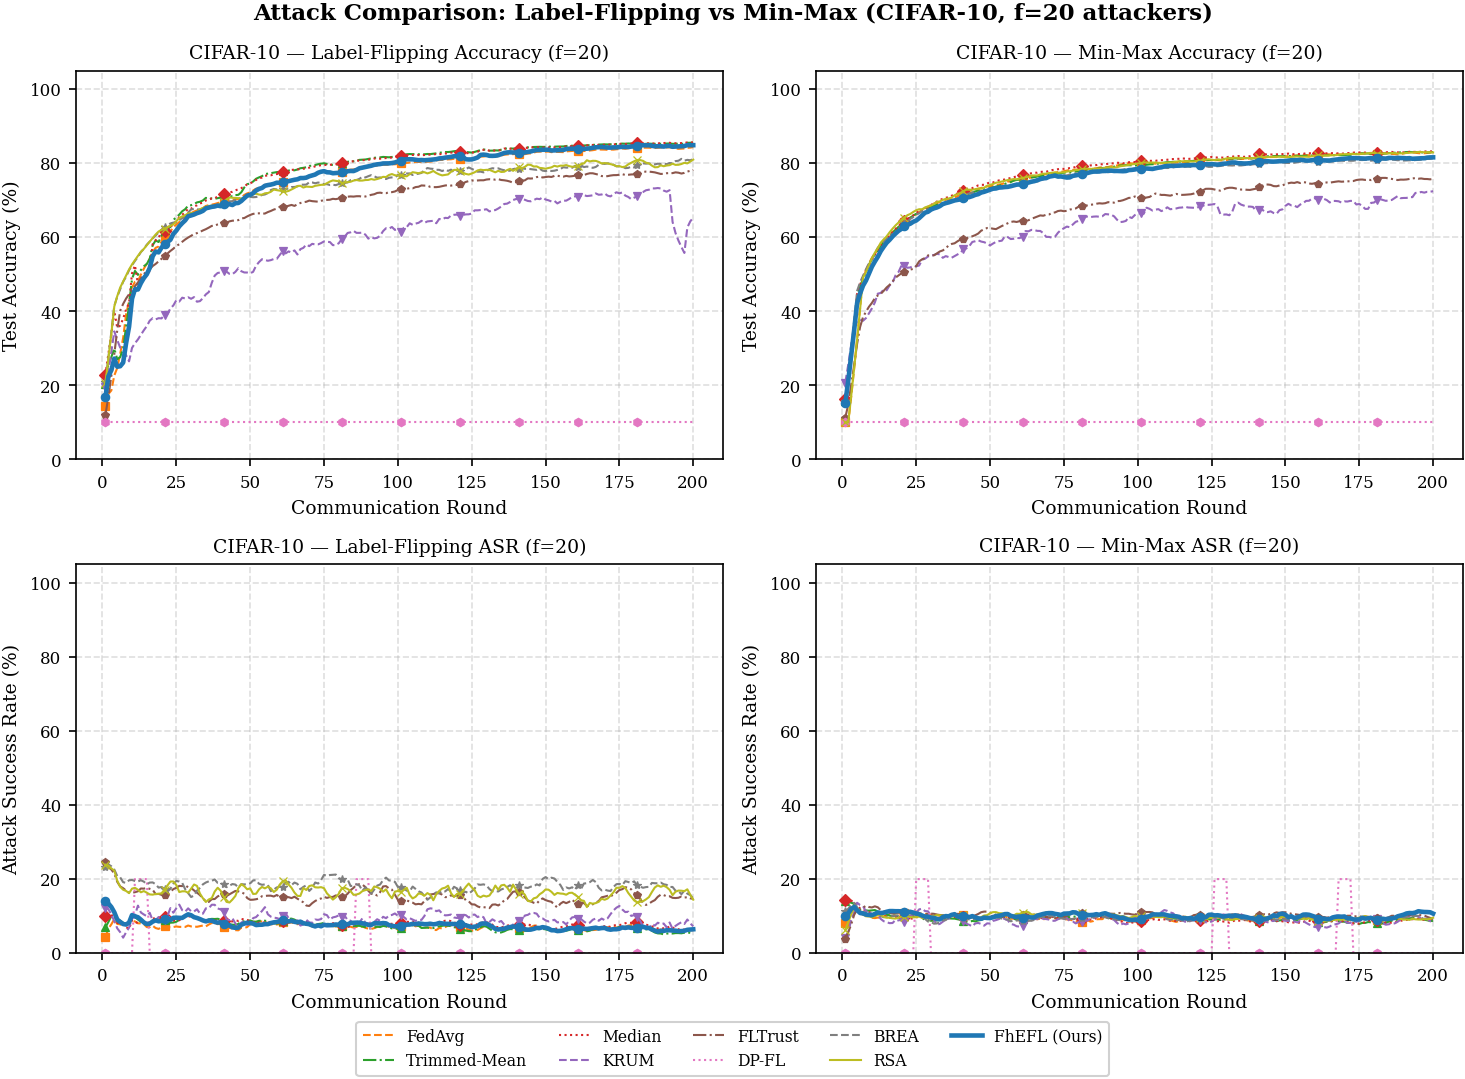

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7))
axs = axs.flatten()

# Panel 1: CIFAR-10 Accuracy - Label-Flipping
ax = axs[0]
plot_panel(ax, "cifar", 20, "accuracy", attack_suffix="", every=20)
ax.set_title("CIFAR-10 — Label-Flipping Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 2: CIFAR-10 Accuracy - Min-Max
ax = axs[1]
plot_panel(ax, "cifar", 20, "accuracy", attack_suffix="_min_max", every=20)
ax.set_title("CIFAR-10 — Min-Max Accuracy (f=20)")
ax.set_ylim([0, 105])

# Panel 3: CIFAR-10 ASR - Label-Flipping
ax = axs[2]
plot_panel(ax, "cifar", 20, "asr", attack_suffix="", every=20)
ax.set_title("CIFAR-10 — Label-Flipping ASR (f=20)")
ax.set_ylim([0, 105])

# Panel 4: CIFAR-10 ASR - Min-Max
ax = axs[3]
plot_panel(ax, "cifar", 20, "asr", attack_suffix="_min_max", every=20)
ax.set_title("CIFAR-10 — Min-Max ASR (f=20)")
ax.set_ylim([0, 105])

fig.legend(handles=[Line2D([0],[0], color=METHODS[n]["color"], ls=METHODS[n]["ls"],
                           lw=METHODS[n]["lw"], label=n) for n in METHODS],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=True)
fig.suptitle("Attack Comparison: Label-Flipping vs Min-Max (CIFAR-10, f=20 attackers)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fig_comparison_label_flipping_vs_minmax_cifar10.pdf", bbox_inches="tight")
plt.savefig(f"{PLOTS_DIR}/fig_comparison_label_flipping_vs_minmax_cifar10.png", bbox_inches="tight")
plt.show()